In [11]:
import rush_hour_reinforce as rf
import rush_hour_rl as rl
import rush_hour_lib as lib
import random
import torch
from sklearn.model_selection import train_test_split


## Pure REINFORCE baseline (no ExIt-style AND-OR imitation)

Trains via `rush_hour_reinforce.ReinforceTrainer` - Monte-Carlo policy gradient (REINFORCE) against real environment rollouts. Every training signal comes from actually playing a puzzle out (`run_episode`, sampling from the policy) and observing whether/how fast it got solved; the reward is a flat -1 per step, so minimizing steps is exactly maximizing return. This mirrors `rush_hour.ipynb`'s structure cell-for-cell so the two approaches are directly comparable on the same puzzle pool.

`ReinforceAgent` subclasses `rush_hour_rl.PolicyAgent` (same board-cell-anchored action space/network, see `car_anchor` in rush_hour_rl.py), so it generalizes across puzzles the same way, and `ReinforceTrainer.evaluate_all()`/`history` match `PuzzleTrainer`'s shape exactly - the plotting cells below are unchanged from the ExIt notebook.

Set `AND_OR_GUIDANCE = True` below to let the agent optionally defer to AND-OR's own recommended move at each step, with probability `1 - confidence` (the policy's own top-action probability at that state) - self-annealing from "mostly AND-OR" early in training to "mostly the learned policy" as it becomes genuinely confident, with no schedule or distance-to-goal threshold to tune. Unlike ExIt/`PuzzleTrainer`, AND-OR here is never a teacher whose demonstrations get imitated across self-play rounds - it's just a per-step oracle the policy can lean on, so none of ExIt's self-play-bias/regression-guard machinery is needed. See `ReinforceAgent.act()`'s docstring for the full mechanism and its one real caveat (a confidently-wrong policy can stop deferring exactly where it most needs to).

In [12]:
GAMMA = 0.99  # REINFORCE's return discount factor - NOT the same GAMMA as rush_hour.ipynb's AND-OR lapse probability
AND_OR_GUIDANCE = True  # let the agent defer to AND-OR's per-step recommendation - see markdown cell above
AND_OR_GAMMA_LAPSE = 0.1  # lapse probability of that guidance oracle's own AND-OR search - see and_or_recommendation
GUIDANCE_SCALE = 1.0  # caps deferral at guidance_scale * (1 - confidence); lower to study the policy gradient's own
                       # improvement more directly, as a cheap stand-in for harder puzzles where AND-OR would also
                       # be less of a crutch - see ReinforceAgent's docstring
HEURISTIC_CONFIDENCE_THRESHOLD = 0.5  # a deferred step's AND-OR search only uses this agent's own .heuristic to
                                       # order its search once confidence clears this bar; below it, AND-OR stays
                                       # policy-blind (uniformly random) so early, low-confidence deferrals get an
                                       # independent demonstration instead of the agent teaching itself from its
                                       # own not-yet-trustworthy judgment - see ReinforceAgent's docstring

In [13]:
SPLIT_SEED = 0  # shuffles which puzzles land in train vs. test - see the split cell below
TRAIN_SIZE = 0.9  # fraction of the cluster pool used for training; the rest is held out as test

In [14]:
puzzles = lib.read_puzzles("data/rush_nw_cluster.txt")

In [15]:
# rush_nw_cluster.txt is a small, hand-picked pool spanning multiple
# distances rather than a single-DIST bucket, so puzzles are pooled across
# every distance present in the file before splitting. train_test_split
# shuffles the pool under SPLIT_SEED and splits it by TRAIN_SIZE - a
# proportion rather than a fixed held-out count, since the pool size varies
# as the cluster file is regenerated. SPLIT_SEED is kept separate from the
# training seed below so reshuffling the split doesn't also change episode
# sampling / the network's initialization, and vice versa.
all_puzzles = [puzzle for dist in sorted(puzzles) for puzzle in puzzles[dist]]
all_distances = [dist for dist in sorted(puzzles) for puzzle in puzzles[dist]]

train_puzzles, test_puzzles, train_distances, test_distances = train_test_split(
    all_puzzles, all_distances, train_size=TRAIN_SIZE, random_state=SPLIT_SEED
)

In [16]:
# Seeded for reproducibility - torch.manual_seed matters as much as
# random.seed here: random.seed alone only controls which puzzles a batched
# iteration samples (see ReinforceTrainer.train's batch_size), not PyTorch's
# weight init / action sampling, a separate source of run-to-run variance.
random.seed(3)
torch.manual_seed(0)

# Each iteration rolls out every train puzzle to max_steps and backprops
# through all of it - ~7-8s/iteration on this 14-puzzle split, plus an
# evaluate_all() (every train + test puzzle, greedy) each eval_every
# iterations - so this is ~5-6 min total, not a quick cell. Raise
# n_iterations once you've confirmed the loop behaves as expected. With
# AND_OR_GUIDANCE off, REINFORCE typically needs many more iterations than
# this to show real learning on a 720-action space with a sparse terminal
# reward; with it on, watch the progress bar's "guided" percentage - it
# should start high (capped by GUIDANCE_SCALE) and trend down as the policy
# grows more confident.
trainer = rf.ReinforceTrainer(train_puzzles, test_puzzles, (6, 6),
                               train_distances=train_distances, test_distances=test_distances, gamma=GAMMA,
                               and_or_guidance=AND_OR_GUIDANCE, and_or_gamma=AND_OR_GAMMA_LAPSE,
                               guidance_scale=GUIDANCE_SCALE,
                               heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD)
policy_loss, train_results, test_results = trainer.train(
    n_iterations=50, max_steps=200, eval_every=5
)
print(f"policy_loss={policy_loss:.3f}")
print(f"train_results={train_results}")
print(f"test_results={test_results}")

REINFORCE iterations: 100%|██████████| 50/50 [02:06<00:00,  2.52s/it, guided=3%, loss=7.465, sampled=12/14]   


policy_loss=7.465
train_results=[(True, 13), (True, 13), (True, 13), (True, 11), (True, 13), (True, 18), (True, 15), (True, 14), (True, 18), (True, 19), (True, 15), (True, 37), (True, 13), (True, 15)]
test_results=[(True, 14), (True, 11)]


In [17]:
import os
os.makedirs("models", exist_ok=True)
trainer.agent.save("models/reinforce_agent.pt")

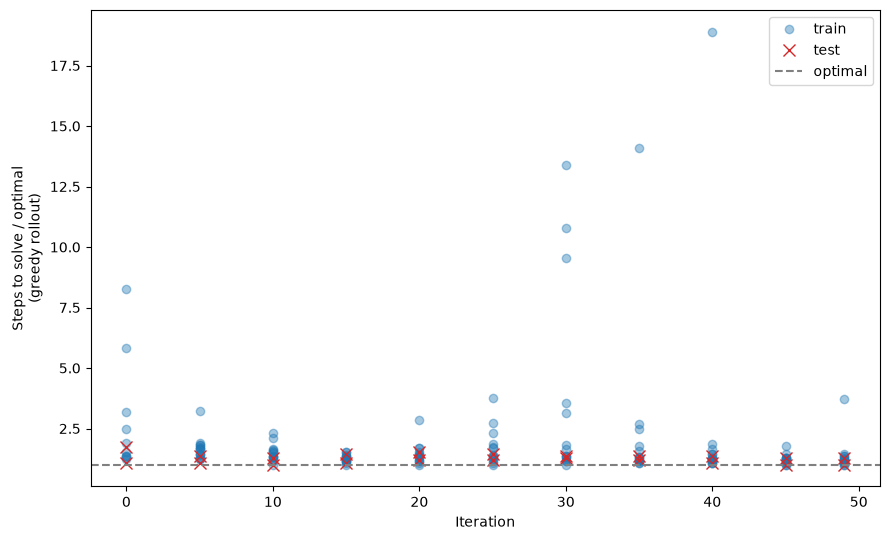

In [18]:
import matplotlib.pyplot as plt

iterations = [it for it, _, _ in trainer.history]

plt.figure(figsize=(9, 5.5))
# linestyle="None": these are isolated solved/unsolved checkpoints, not a
# continuous quantity - a connecting line would draw a straight (and
# misleading) segment across iterations that didn't solve (nan) in between.
# Steps are normalized by each puzzle's own optimal length (train_distances/
# test_distances), same as rush_hour.ipynb's equivalent plot, since the pool
# spans multiple distances rather than one shared DIST.
for i in range(len(train_puzzles)):
    steps = [train_i[i][1] / train_distances[i] for _, train_i, _ in trainer.history]
    plt.plot(iterations, steps, marker="o", linestyle="None", color="tab:blue", alpha=0.4,
              label="train" if i == 0 else None)
for i in range(len(test_puzzles)):
    steps = [test_i[i][1] / test_distances[i] for _, _, test_i in trainer.history]
    plt.plot(iterations, steps, marker="x", linestyle="None", color="tab:red", markersize=8,
              label="test" if i == 0 else None)
plt.axhline(1.0, color="gray", linestyle="--", label="optimal")
plt.xlabel("Iteration"); plt.ylabel("Steps to solve / optimal\n(greedy rollout)")
plt.legend()
plt.tight_layout()
plt.savefig("visualization/reinforce_bc.png")
plt.show()

## Fine-tuning convergence: pretrained vs. scratch

Mirrors rush_hour.ipynb's fine-tuning section: each (capped) test puzzle gets fine-tuned on directly via `rf.finetune_curve` (REINFORCE's counterpart to `rl.finetune_curve` - same single-puzzle-trainer shape, policy-gradient updates instead of heuristic-guided AND-OR + supervised training), starting once from the saved pretrained checkpoint and once from a fresh, randomly-initialized agent. `rl.average_curves` is reused unchanged, since `rf.finetune_curve`'s output has the same (epoch, solved, steps) shape as `rl.finetune_curve`'s.

In [19]:
FT_KWARGS = dict(n_iterations=30, max_steps=200, eval_every=1, gamma=GAMMA)

# Same reasoning as rush_hour.ipynb's fine-tune cell: this loop trains two
# full agents (pretrained + scratch) per puzzle, so its cost scales directly
# with how many puzzles it's given - capped to a handful rather than run
# over every held-out test puzzle. train_puzzles/test_puzzles themselves
# (used by the trainer.train() cell above) are left untouched.
#
# AND_OR_GUIDANCE/AND_OR_GAMMA_LAPSE/GUIDANCE_SCALE/
# HEURISTIC_CONFIDENCE_THRESHOLD (set above) apply here too now: guidance
# isn't part of the saved checkpoint (see ReinforceAgent's docstring), so
# ReinforceAgent.load() takes it as a fresh argument, same as the scratch
# agent's own constructor call.
FT_TEST_SIZE = 5
ft_test_puzzles = test_puzzles[:FT_TEST_SIZE]
ft_test_distances = test_distances[:FT_TEST_SIZE]

pretrained_curves, scratch_curves = [], []
for i, puzzle in enumerate(ft_test_puzzles):
    random.seed(100 + i); torch.manual_seed(100 + i)
    pretrained_curves.append(rf.finetune_curve(
        rf.ReinforceAgent.load("models/reinforce_agent.pt", and_or_guidance=AND_OR_GUIDANCE,
                                and_or_gamma=AND_OR_GAMMA_LAPSE, guidance_scale=GUIDANCE_SCALE,
                                heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD),
        puzzle, (6, 6), desc=f"pretrained {i + 1}/{len(ft_test_puzzles)}", **FT_KWARGS))

    random.seed(100 + i); torch.manual_seed(100 + i)
    scratch_curves.append(rf.finetune_curve(
        rf.ReinforceAgent((6, 6), and_or_guidance=AND_OR_GUIDANCE,
                           and_or_gamma=AND_OR_GAMMA_LAPSE, guidance_scale=GUIDANCE_SCALE,
                           heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD),
        puzzle, (6, 6), desc=f"scratch {i + 1}/{len(ft_test_puzzles)}", **FT_KWARGS))

scratch 2/2: 100%|██████████| 30/30 [00:06<00:00,  4.42it/s, guided=0%, loss=-0.000, sampled=0/1]  


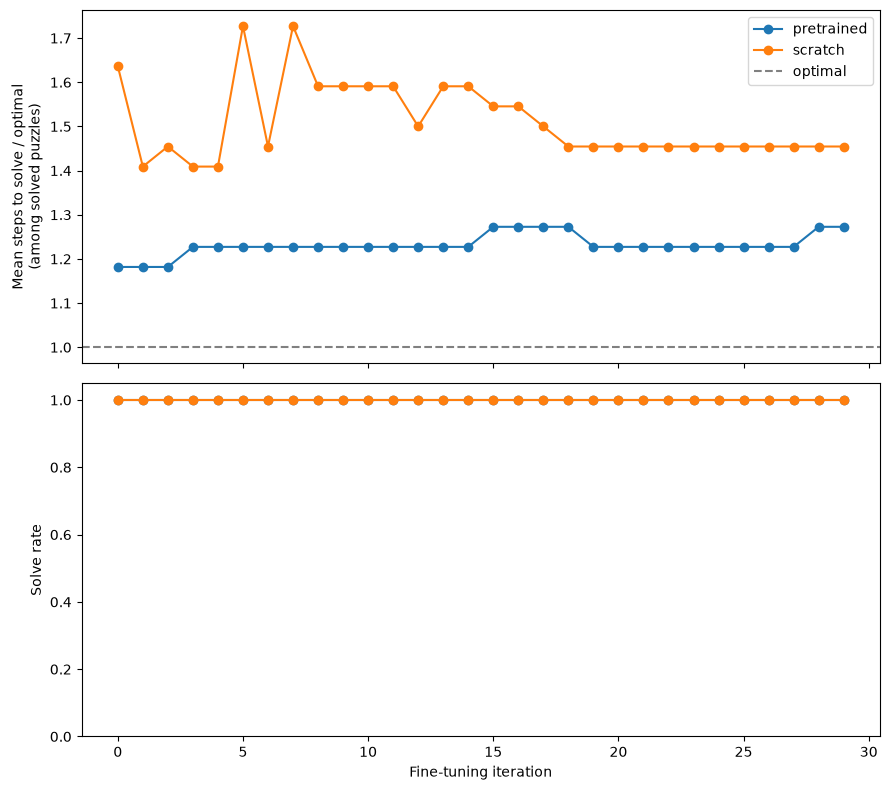

In [20]:
pre_epochs, pre_steps, pre_rate = rl.average_curves(pretrained_curves, optimal=ft_test_distances)
scr_epochs, scr_steps, scr_rate = rl.average_curves(scratch_curves, optimal=ft_test_distances)

fig, (ax_steps, ax_rate) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_steps.plot(pre_epochs, pre_steps, marker="o", color="tab:blue", label="pretrained")
ax_steps.plot(scr_epochs, scr_steps, marker="o", color="tab:orange", label="scratch")
ax_steps.axhline(1.0, color="gray", linestyle="--", label="optimal")
ax_steps.set_ylabel("Mean steps to solve / optimal\n(among solved puzzles)")
ax_steps.legend()

ax_rate.plot(pre_epochs, pre_rate, marker="o", color="tab:blue", label="pretrained")
ax_rate.plot(scr_epochs, scr_rate, marker="o", color="tab:orange", label="scratch")
ax_rate.set_ylim(0, 1.05)
ax_rate.set_xlabel("Fine-tuning iteration")
ax_rate.set_ylabel("Solve rate")

plt.tight_layout()
plt.savefig("visualization/reinforce_finetune_convergence.png")
plt.show()